In [96]:
#!pip install category_encoders
#!pip install kagglehub
#!pip install matplotlib
#!pip install seaborn
#!pip install hvplot holoviews bokeh panel param
#!pip install numpy

In [179]:
import kagglehub
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import category_encoders as ce
import hvplot.pandas
import holoviews as hv
import math
hv.extension('bokeh') 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score, roc_curve
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

In [98]:
# Download latest version
path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

print("Path to dataset files:", path)

# Assuming 'aug_train.csv' is the primary data file within the dataset directory
perf_path = 'WA_Fn-UseC_-HR-Employee-Attrition.csv'
full_csv_path = os.path.join(path, perf_path)

# Check if the file exists before attempting to read
if os.path.exists(full_csv_path):
    df = pd.read_csv(full_csv_path)
    print(f"Successfully loaded {perf_path} into a DataFrame.")
    display(df.head())
else:
    print(f"Error: The file '{perf_path}' was not found in '{path}'.")
    print("Available files in the directory:", os.listdir(path))

Path to dataset files: /Users/Afshin/.cache/kagglehub/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/versions/1
Successfully loaded WA_Fn-UseC_-HR-Employee-Attrition.csv into a DataFrame.


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# New Section

In [99]:
df.shape

(1470, 35)

In [100]:
df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [101]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

<Axes: xlabel='Attrition', ylabel='count'>

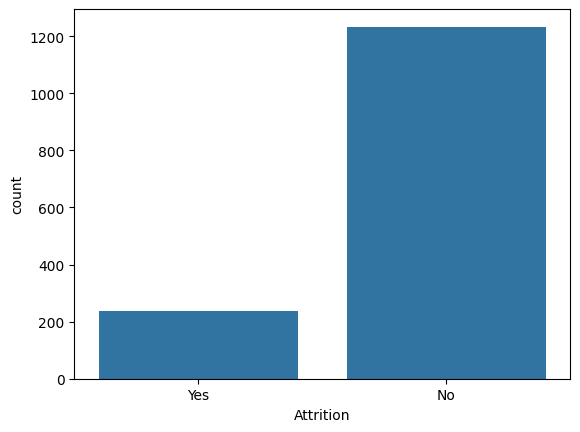

In [103]:
sns.countplot(x='Attrition', data=df)

In [104]:
for i in df.columns:
  print(i)

Age
Attrition
BusinessTravel
DailyRate
Department
DistanceFromHome
Education
EducationField
EmployeeCount
EmployeeNumber
EnvironmentSatisfaction
Gender
HourlyRate
JobInvolvement
JobLevel
JobRole
JobSatisfaction
MaritalStatus
MonthlyIncome
MonthlyRate
NumCompaniesWorked
Over18
OverTime
PercentSalaryHike
PerformanceRating
RelationshipSatisfaction
StandardHours
StockOptionLevel
TotalWorkingYears
TrainingTimesLastYear
WorkLifeBalance
YearsAtCompany
YearsInCurrentRole
YearsSinceLastPromotion
YearsWithCurrManager


In [105]:
#Number of unique values per column

lista={}
for i in df.columns:
  #lista[i] = df[i].nunique()
  print(i, ':', df[i].nunique())

Age : 43
Attrition : 2
BusinessTravel : 3
DailyRate : 886
Department : 3
DistanceFromHome : 29
Education : 5
EducationField : 6
EmployeeCount : 1
EmployeeNumber : 1470
EnvironmentSatisfaction : 4
Gender : 2
HourlyRate : 71
JobInvolvement : 4
JobLevel : 5
JobRole : 9
JobSatisfaction : 4
MaritalStatus : 3
MonthlyIncome : 1349
MonthlyRate : 1427
NumCompaniesWorked : 10
Over18 : 1
OverTime : 2
PercentSalaryHike : 15
PerformanceRating : 2
RelationshipSatisfaction : 4
StandardHours : 1
StockOptionLevel : 4
TotalWorkingYears : 40
TrainingTimesLastYear : 7
WorkLifeBalance : 4
YearsAtCompany : 37
YearsInCurrentRole : 19
YearsSinceLastPromotion : 16
YearsWithCurrManager : 18


In [106]:
df[['Over18', 'StandardHours', 'EmployeeCount']].value_counts()

Over18  StandardHours  EmployeeCount
Y       80             1                1470
Name: count, dtype: int64

In [107]:
# Fix: Drop the 'Over18' column by name and specify axis=1
df = df.drop('Over18', axis=1)
df = df.drop('StandardHours', axis=1)
df = df.drop('EmployeeCount', axis=1)
df = df.drop('EmployeeNumber', axis=1)

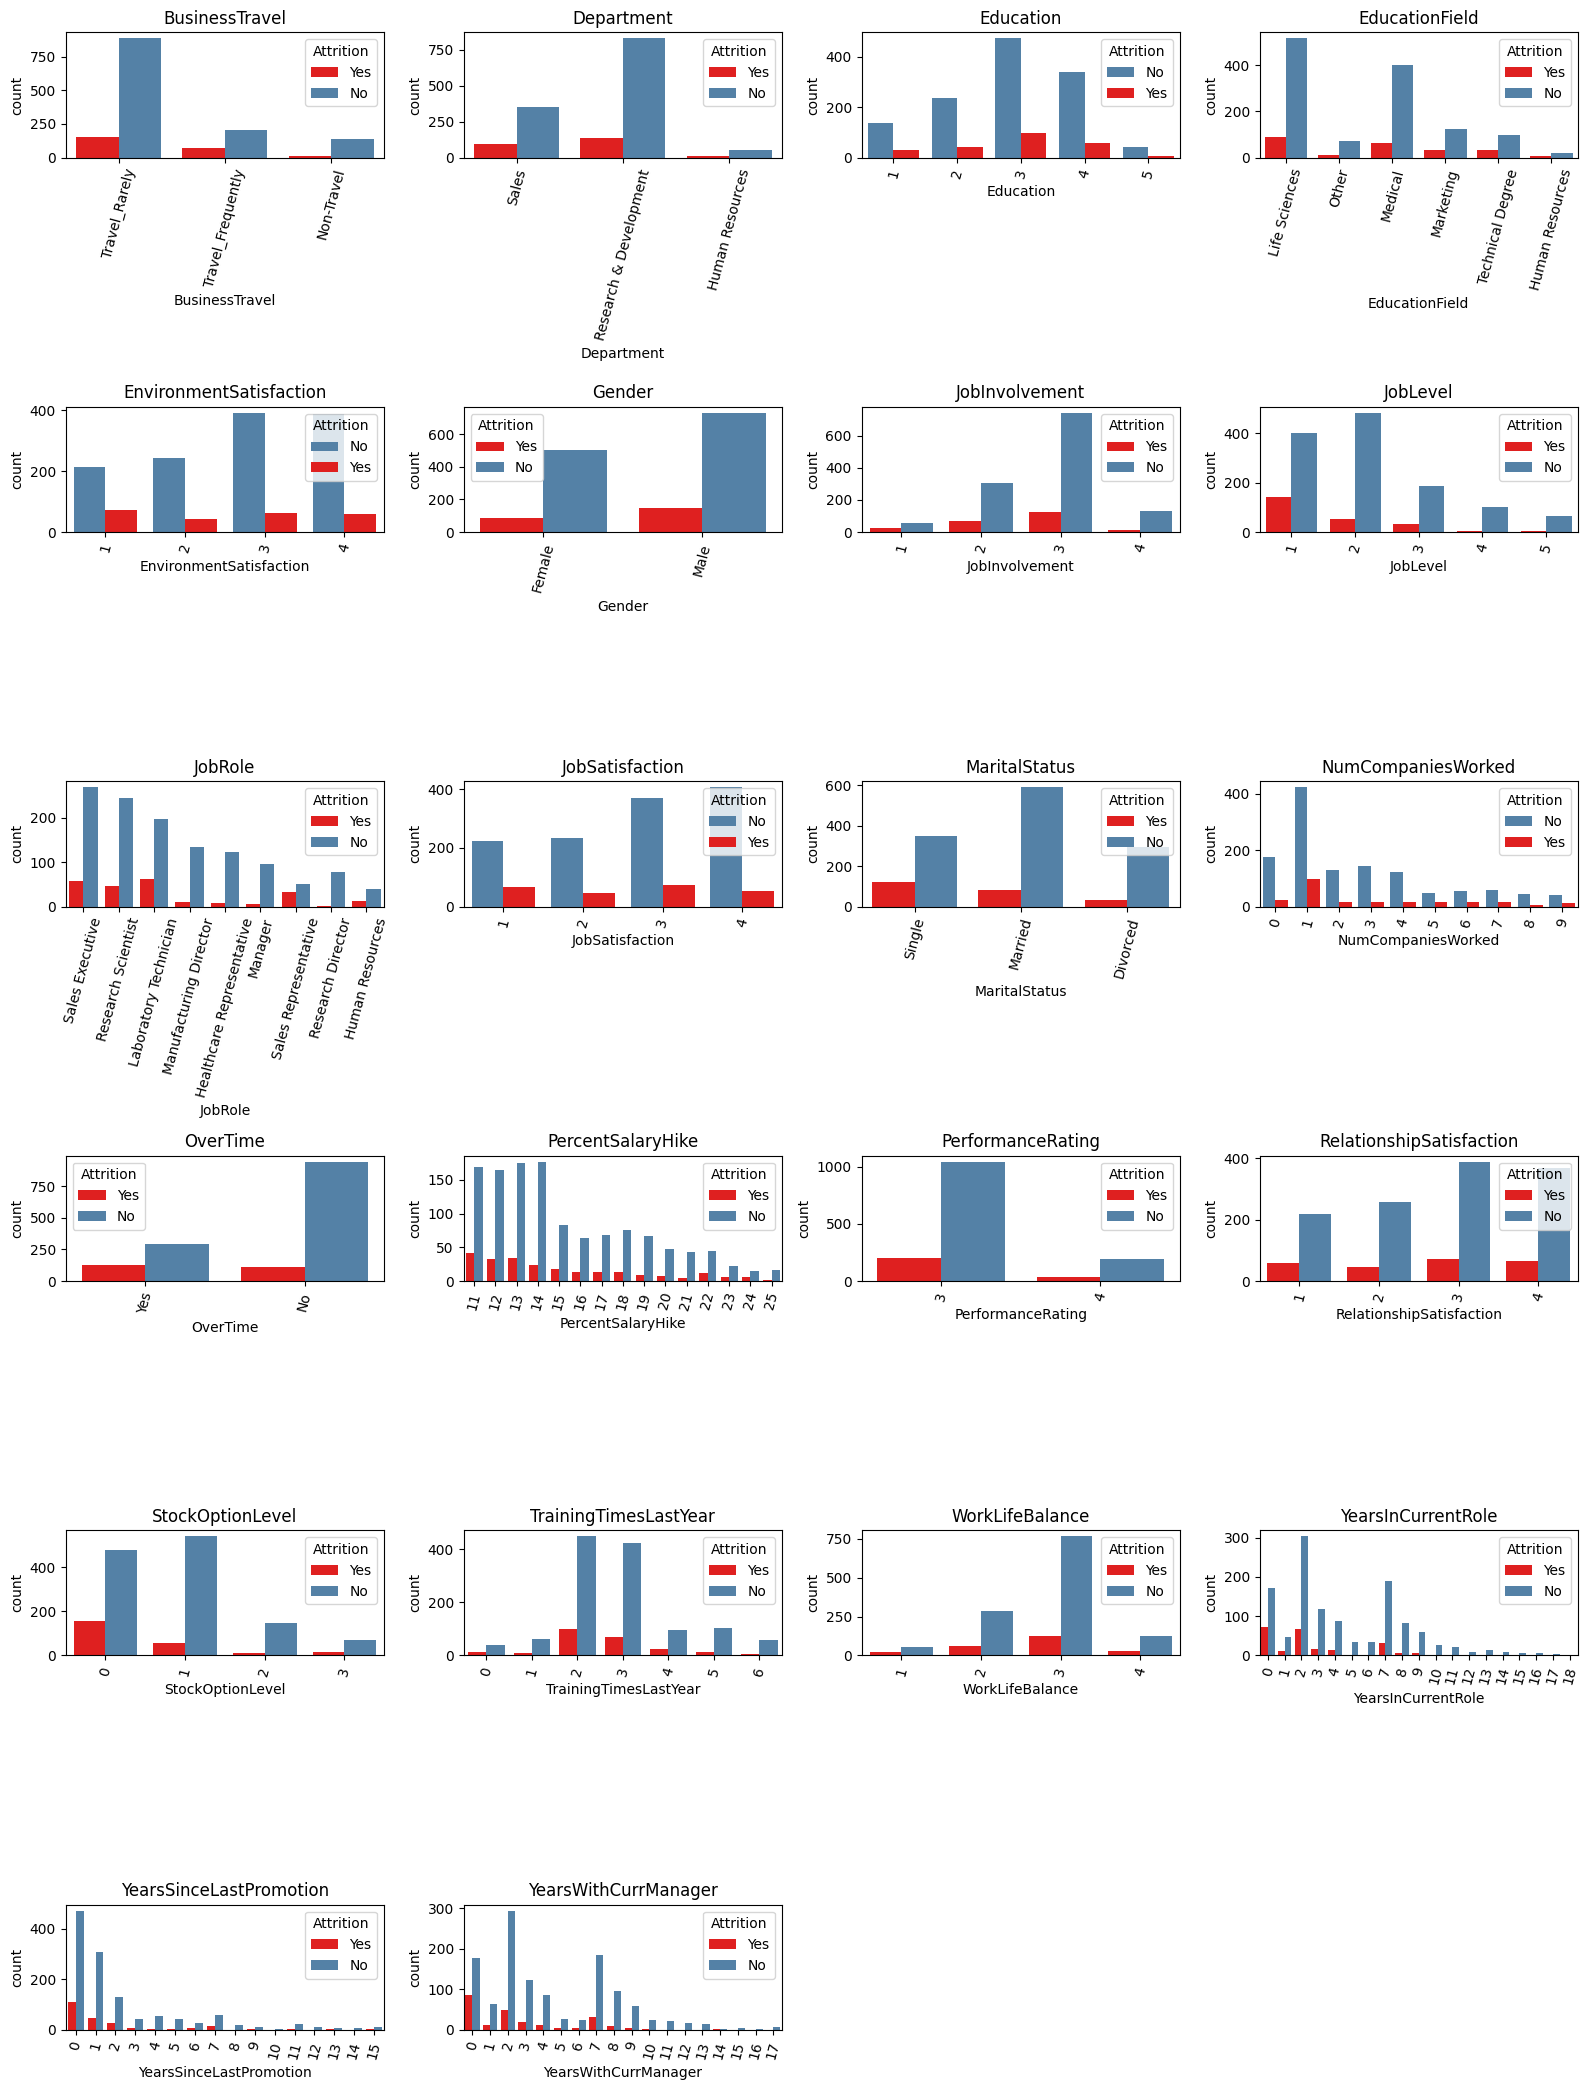

In [108]:
attrition_palette = {'No': 'steelblue', 'Yes': 'red'}

plot_columns = [col for col in df.columns if len(df[col].unique()) < 21 and col != 'Attrition']

num_plots = len(plot_columns)
num_cols = 4
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 4, num_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(plot_columns):
    sns.countplot(x=col, hue='Attrition', data=df, ax=axes[i], palette=attrition_palette)
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=75)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [109]:
#All non-integer columns

print(df.dtypes[df.dtypes == 'object'])

Attrition         object
BusinessTravel    object
Department        object
EducationField    object
Gender            object
JobRole           object
MaritalStatus     object
OverTime          object
dtype: object


In [110]:
df['Attrition'] = df['Attrition'].apply(lambda x: 1 if x=='Yes' else 0)
df['Gender'] = df['Gender'].apply(lambda x: 1 if x=='Male' else 0)

In [111]:
df[(df.dtypes[df.dtypes == 'int64']).keys().to_numpy()]

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,1102,1,2,2,0,94,3,2,...,3,1,0,8,0,1,6,4,0,5
1,49,0,279,8,1,3,1,61,2,2,...,4,4,1,10,3,3,10,7,1,7
2,37,1,1373,2,2,4,1,92,2,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1392,3,4,4,0,56,3,1,...,3,3,0,8,3,3,8,7,3,0
4,27,0,591,2,1,1,1,40,3,1,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,23,2,3,1,41,4,2,...,3,3,1,17,3,3,5,2,0,3
1466,39,0,613,6,1,4,1,42,2,3,...,3,1,1,9,5,3,7,7,1,7
1467,27,0,155,4,3,2,1,87,4,2,...,4,2,1,6,0,3,6,2,0,3
1468,49,0,1023,2,3,4,1,63,2,2,...,3,4,0,17,3,2,9,6,0,8


<Axes: >

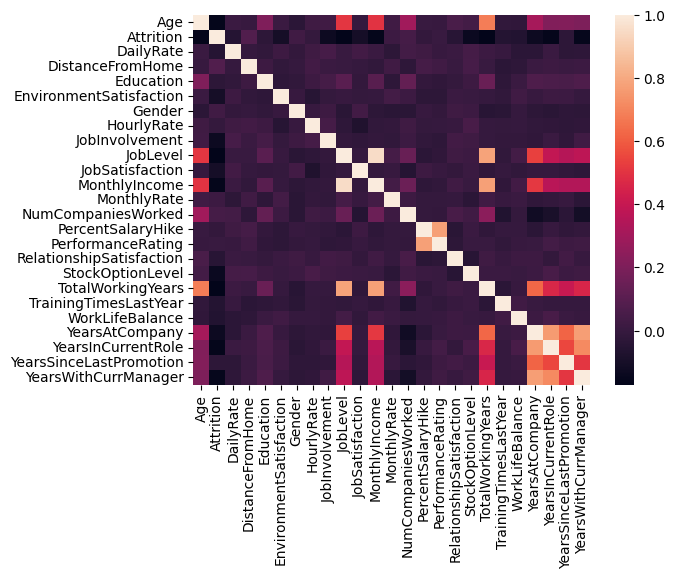

In [112]:
sns.heatmap(df[(df.dtypes[df.dtypes == 'int64']).keys().to_numpy()].corr())

In [113]:
df[(df.dtypes[df.dtypes == 'int64']).keys().to_numpy()]

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,1102,1,2,2,0,94,3,2,...,3,1,0,8,0,1,6,4,0,5
1,49,0,279,8,1,3,1,61,2,2,...,4,4,1,10,3,3,10,7,1,7
2,37,1,1373,2,2,4,1,92,2,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1392,3,4,4,0,56,3,1,...,3,3,0,8,3,3,8,7,3,0
4,27,0,591,2,1,1,1,40,3,1,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,23,2,3,1,41,4,2,...,3,3,1,17,3,3,5,2,0,3
1466,39,0,613,6,1,4,1,42,2,3,...,3,1,1,9,5,3,7,7,1,7
1467,27,0,155,4,3,2,1,87,4,2,...,4,2,1,6,0,3,6,2,0,3
1468,49,0,1023,2,3,4,1,63,2,2,...,3,4,0,17,3,2,9,6,0,8


In [ ]:
#categorical_cols = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'OverTime', 'MaritalStatus']
numerical_cols = df.dtypes[df.dtypes == 'int64'].index.to_list()
categorical_cols = df.dtypes[df.dtypes == 'object'].index.to_list()
categorical_cols

['BusinessTravel',
 'Department',
 'EducationField',
 'JobRole',
 'MaritalStatus',
 'OverTime']

In [115]:
# Separate features (X) and target (y)
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# validation split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.20, stratify=y_train)

#categorical_cols = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'OverTime', 'MaritalStatus']
#OneHotEncoder
ohe = ce.OneHotEncoder(cols=categorical_cols)
X_train_encoded = ohe.fit_transform(X_train)
X_test_encoded = ohe.transform(X_test)
X_val_encoded = ohe.fit_transform(X_val)

#Scaling the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)
X_val_scaled = scaler.fit_transform(X_val_encoded)

In [116]:
#LogRegression

#Model Def
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

#Predict and Score
y_pred_lr = lr.predict(X_val_scaled)
f1_lr = f1_score(y_val, y_pred_lr)
accuracy_lr = accuracy_score(y_val, y_pred_lr)
recall_lr = recall_score(y_val, y_pred_lr)
precision_lr = precision_score(y_val, y_pred_lr)
roc_lr = roc_auc_score(y_val, y_pred_lr)

print(f1_lr , ',' , accuracy_lr , ',' , recall_lr , ',' , precision_lr , ',' , roc_lr)


0.3492063492063492 , 0.826271186440678 , 0.2894736842105263 , 0.44 , 0.6093833067517278


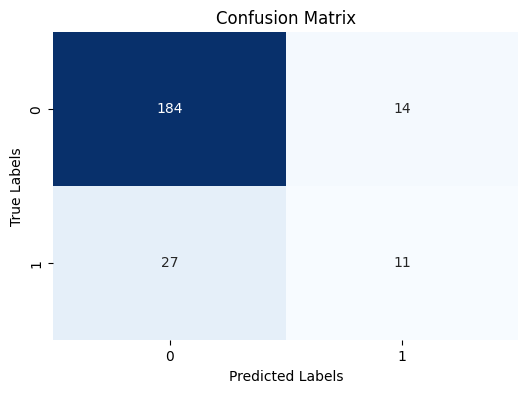

In [117]:
def plot_confusion_matrix(cm):
    # Plotting the confusion matrix
    plt.figure(figsize=(6,4));
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False);  # fmt='g' is for integer formatting
    plt.xlabel('Predicted Labels');
    plt.ylabel('True Labels');
    plt.title('Confusion Matrix');
    plt.show();


cm = confusion_matrix(y_val, y_pred_lr)

plot_confusion_matrix(cm)

In [118]:
#RandomForest

#Model Def
rf = RandomForestClassifier()
rf.fit(X_train_encoded, y_train)

#Predict and Score
y_pred_rf = rf.predict(X_val_encoded)
f1_rf = f1_score(y_val, y_pred_rf)
accuracy_rf = accuracy_score(y_val, y_pred_rf)
recall_rf = recall_score(y_val, y_pred_rf)
precision_rf = precision_score(y_val, y_pred_rf)
roc_rf = roc_auc_score(y_val, y_pred_rf)

print(f1_rf , ',' , accuracy_rf , ',' , recall_rf , ',' , precision_rf , ',' , roc_rf)

0.18604651162790697 , 0.8516949152542372 , 0.10526315789473684 , 0.8 , 0.5501063264221159


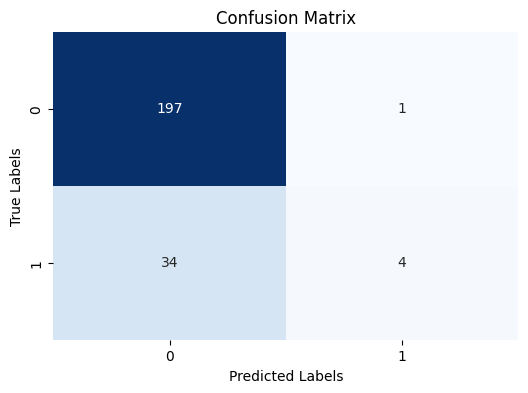

In [119]:
def plot_confusion_matrix(cm):
    # Plotting the confusion matrix
    plt.figure(figsize=(6,4));
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False);  # fmt='g' is for integer formatting
    plt.xlabel('Predicted Labels');
    plt.ylabel('True Labels');
    plt.title('Confusion Matrix');
    plt.show();


cm = confusion_matrix(y_val, y_pred_rf)

plot_confusion_matrix(cm)

In [120]:
df[numerical_cols].min()

Age                           18
Attrition                      0
DailyRate                    102
DistanceFromHome               1
Education                      1
EnvironmentSatisfaction        1
Gender                         0
HourlyRate                    30
JobInvolvement                 1
JobLevel                       1
JobSatisfaction                1
MonthlyIncome               1009
MonthlyRate                 2094
NumCompaniesWorked             0
PercentSalaryHike             11
PerformanceRating              3
RelationshipSatisfaction       1
StockOptionLevel               0
TotalWorkingYears              0
TrainingTimesLastYear          0
WorkLifeBalance                1
YearsAtCompany                 0
YearsInCurrentRole             0
YearsSinceLastPromotion        0
YearsWithCurrManager           0
dtype: int64

In [121]:
df[numerical_cols].max()

Age                            60
Attrition                       1
DailyRate                    1499
DistanceFromHome               29
Education                       5
EnvironmentSatisfaction         4
Gender                          1
HourlyRate                    100
JobInvolvement                  4
JobLevel                        5
JobSatisfaction                 4
MonthlyIncome               19999
MonthlyRate                 26999
NumCompaniesWorked              9
PercentSalaryHike              25
PerformanceRating               4
RelationshipSatisfaction        4
StockOptionLevel                3
TotalWorkingYears              40
TrainingTimesLastYear           6
WorkLifeBalance                 4
YearsAtCompany                 40
YearsInCurrentRole             18
YearsSinceLastPromotion        15
YearsWithCurrManager           17
dtype: int64

In [122]:
aux_vec = ['StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
'YearsSinceLastPromotion', 'YearsWithCurrManager']
print('Min:', '\n',  df[aux_vec].min(), '\n', 'Max:' , '\n' , df[aux_vec].max(),)


Min: 
 StockOptionLevel           0
TotalWorkingYears          0
TrainingTimesLastYear      0
WorkLifeBalance            1
YearsAtCompany             0
YearsInCurrentRole         0
YearsSinceLastPromotion    0
YearsWithCurrManager       0
dtype: int64 
 Max: 
 StockOptionLevel            3
TotalWorkingYears          40
TrainingTimesLastYear       6
WorkLifeBalance             4
YearsAtCompany             40
YearsInCurrentRole         18
YearsSinceLastPromotion    15
YearsWithCurrManager       17
dtype: int64


In [123]:
aux_monthrate = np.linspace(df['MonthlyRate'].min(), df['MonthlyRate'].max(), 8)
#intervals = df['MonthlyRate'].value_counts(bins=aux_monthrate).sort_index()
attrition_monthlyrate = df.groupby(pd.cut(df['MonthlyRate'], bins = aux_monthrate, include_lowest=True))['Attrition'].mean()*100
print(attrition_monthlyrate.sort_values(ascending=False))
df.hvplot.hist(y='MonthlyRate', by='Attrition', subplots=False, height=300, bins= aux_monthrate)

MonthlyRate
(9209.714, 12767.571]     18.660287
(23441.143, 26999.0]      17.318436
(19883.286, 23441.143]    16.666667
(2093.999, 5651.857]      15.765766
(12767.571, 16325.429]    15.639810
(16325.429, 19883.286]    15.533981
(5651.857, 9209.714]      13.488372
Name: Attrition, dtype: float64


/Users/Afshin/Library/Python/3.9/lib/python/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/var/folders/xb/9897psnj1ws_rdqp0k223d740000gp/T/ipykernel_859/524645943.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attrition_monthlyrate = df.groupby(pd.cut(df['MonthlyRate'], bins = aux_monthrate, include_lowest=True))['Attrition'].mean()*100


:NdOverlay   [Attrition]
   :Histogram   [MonthlyRate]   (Count)

In [124]:
cols_aux= 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager'
plots= []

for col in cols_aux:
    bins_aux = np.linspace(df[col].min(), df[col].max(), 8)
    step = np.ceil((df[col].max() - df[col].min()) / 6)
    bins_aux = np.arange(df[col].min(), df[col].max() + step, step)
    attrition = df.groupby(pd.cut(df[col], bins = bins_aux, include_lowest=True))['Attrition'].mean()*100
    graph = df.hvplot.hist(y=col, by='Attrition', subplots=False, height=300, bins= bins_aux, title=col)
    plots.append(graph)

all_plots = hv.Layout(plots).cols(len(cols_aux))
all_plots


/Users/Afshin/Library/Python/3.9/lib/python/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/var/folders/xb/9897psnj1ws_rdqp0k223d740000gp/T/ipykernel_859/1673820166.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attrition = df.groupby(pd.cut(df[col], bins = bins_aux, include_lowest=True))['Attrition'].mean()*100


:Layout
   .NdOverlay.I    :NdOverlay   [Attrition]
      :Histogram   [StockOptionLevel]   (Count)
   .NdOverlay.II   :NdOverlay   [Attrition]
      :Histogram   [TotalWorkingYears]   (Count)
   .NdOverlay.III  :NdOverlay   [Attrition]
      :Histogram   [TrainingTimesLastYear]   (Count)
   .NdOverlay.IV   :NdOverlay   [Attrition]
      :Histogram   [WorkLifeBalance]   (Count)
   .NdOverlay.V    :NdOverlay   [Attrition]
      :Histogram   [YearsAtCompany]   (Count)
   .NdOverlay.VI   :NdOverlay   [Attrition]
      :Histogram   [YearsInCurrentRole]   (Count)
   .NdOverlay.VII  :NdOverlay   [Attrition]
      :Histogram   [YearsSinceLastPromotion]   (Count)
   .NdOverlay.VIII :NdOverlay   [Attrition]
      :Histogram   [YearsWithCurrManager]   (Count)

In [125]:
numerical_summary = df[numerical_cols].apply(lambda x: {
    'uni': x.nunique(),
    'tp': x.dtype,
    'mx': x.max(),
    'mn': x.min()
})
numerical_summary

Age                              {'uni': 43, 'tp': int64, 'mx': 60, 'mn': 18}
Attrition                           {'uni': 2, 'tp': int64, 'mx': 1, 'mn': 0}
DailyRate                    {'uni': 886, 'tp': int64, 'mx': 1499, 'mn': 102}
DistanceFromHome                  {'uni': 29, 'tp': int64, 'mx': 29, 'mn': 1}
Education                           {'uni': 5, 'tp': int64, 'mx': 5, 'mn': 1}
EnvironmentSatisfaction             {'uni': 4, 'tp': int64, 'mx': 4, 'mn': 1}
Gender                              {'uni': 2, 'tp': int64, 'mx': 1, 'mn': 0}
HourlyRate                      {'uni': 71, 'tp': int64, 'mx': 100, 'mn': 30}
JobInvolvement                      {'uni': 4, 'tp': int64, 'mx': 4, 'mn': 1}
JobLevel                            {'uni': 5, 'tp': int64, 'mx': 5, 'mn': 1}
JobSatisfaction                     {'uni': 4, 'tp': int64, 'mx': 4, 'mn': 1}
MonthlyIncome               {'uni': 1349, 'tp': int64, 'mx': 19999, 'mn': ...
MonthlyRate                 {'uni': 1427, 'tp': int64, 'mx': 269

In [126]:
categorical_summary = df[categorical_cols].apply(lambda x: {
    'uni': x.nunique(),
    'tp': x.dtype
})
categorical_summary

BusinessTravel    {'uni': 3, 'tp': object}
Department        {'uni': 3, 'tp': object}
EducationField    {'uni': 6, 'tp': object}
JobRole           {'uni': 9, 'tp': object}
MaritalStatus     {'uni': 3, 'tp': object}
OverTime          {'uni': 2, 'tp': object}
dtype: object

In [127]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [128]:
df[['HourlyRate', 'DailyRate', 'MonthlyRate', 'MonthlyIncome']].describe()

,HourlyRate,DailyRate,MonthlyRate,MonthlyIncome
count,1470.000000,1470.000000,1470.000000,1470.000000
mean,65.891156,802.485714,14313.103401,6502.931293
std,20.329428,403.509100,7117.786044,4707.956783
min,30.000000,102.000000,2094.000000,1009.000000
25%,48.000000,465.000000,8047.000000,2911.000000
50%,66.000000,802.000000,14235.500000,4919.000000
75%,83.750000,1157.000000,20461.500000,8379.000000
max,100.000000,1499.000000,26999.000000,19999.000000


<Axes: >

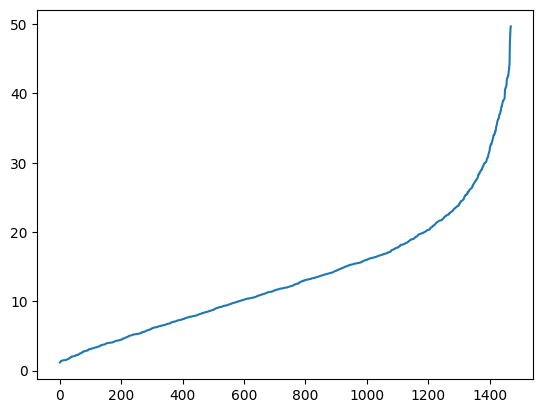

In [129]:
df['new1'] = (df['DailyRate']/df['HourlyRate']) #Supposed hours needed in a day
df['new1'].sort_values().reset_index(drop=True).plot()


<Axes: >

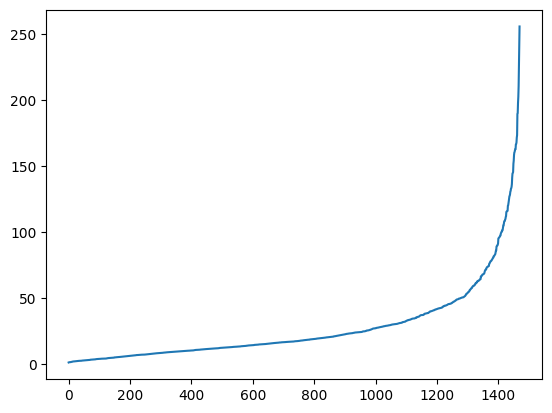

In [130]:
df['new2'] = (df['MonthlyRate']/df['DailyRate']) #Supposed days needed in a month
df['new2'].sort_values().reset_index(drop=True).plot()

<Axes: >

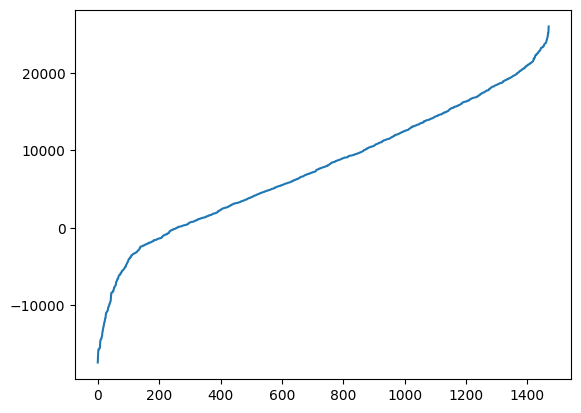

In [131]:
df['new3'] = (df['MonthlyRate'] - df['MonthlyIncome']) #Diff between Monthly Rate and Monthly Income
df['new3'].sort_values().reset_index(drop=True).plot()

In [132]:
df.groupby('Attrition')['Education'].value_counts()

Attrition  Education
0          3            473
           4            340
           2            238
           1            139
           5             43
1          3             99
           4             58
           2             44
           1             31
           5              5
Name: count, dtype: int64

In [133]:
df['PercentSalaryHike'].value_counts()

PercentSalaryHike
11    210
13    209
14    201
12    198
15    101
18     89
17     82
16     78
19     76
22     56
20     55
21     48
23     28
24     21
25     18
Name: count, dtype: int64

In [136]:
df[df['Gender']==1]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,new1,new2,new3
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,1,...,10,3,3,10,7,1,7,4.573770,89.272401,19777
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,1,...,7,3,3,0,0,0,0,14.923913,1.745084,306
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,1,...,6,3,3,2,2,2,2,14.775000,28.142132,13164
5,32,0,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,4,1,...,8,2,2,7,7,3,6,12.721519,11.804975,8796
7,30,0,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,4,1,...,1,2,3,1,0,0,0,20.268657,9.819588,10642
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,Travel_Frequently,884,Research & Development,23,2,Medical,3,1,...,17,3,3,5,2,0,3,21.560976,13.902715,9719
1466,39,0,Travel_Rarely,613,Research & Development,6,1,Medical,4,1,...,9,5,3,7,7,1,7,14.595238,35.003263,11466
1467,27,0,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2,1,...,6,0,3,6,2,0,3,1.781609,33.380645,-968
1468,49,0,Travel_Frequently,1023,Sales,2,3,Medical,4,1,...,17,3,2,9,6,0,8,16.238095,12.945259,7853


<Axes: xlabel='Gender'>

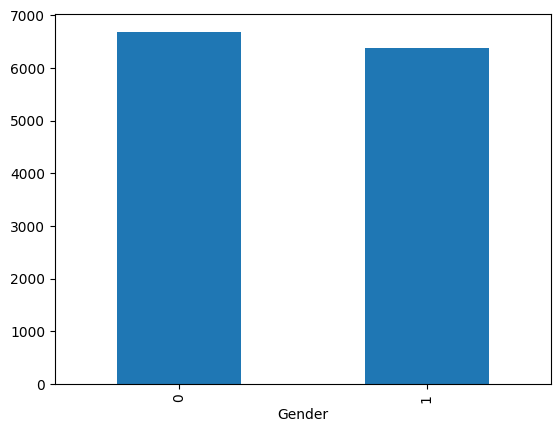

In [ ]:
aux_var = df.groupby('Gender')['MonthlyIncome']
aux_var.mean().plot(kind='bar', x)

<Axes: xlabel='Age'>

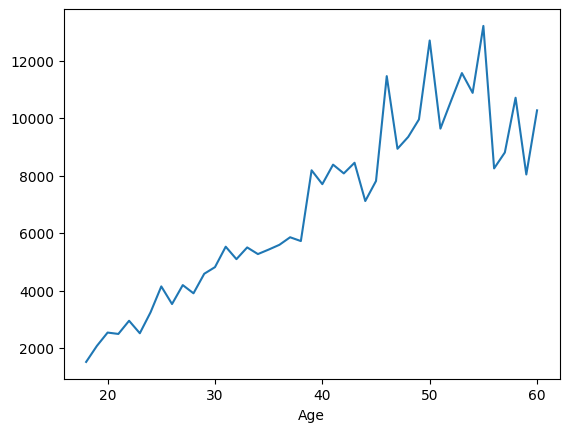

In [149]:
aux_var = df.groupby('Age')['MonthlyIncome']
aux_var.mean().plot()

<Axes: xlabel='Education'>

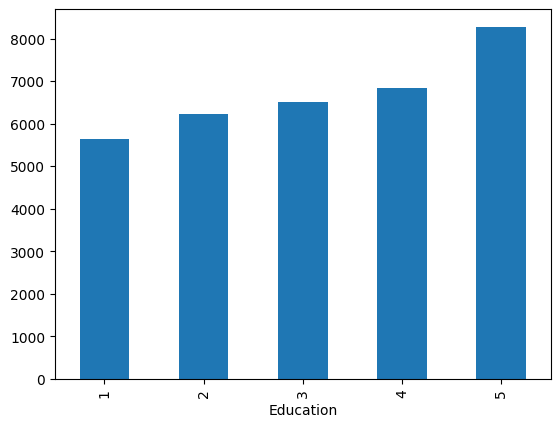

In [152]:
aux_var = df.groupby('Education')['MonthlyIncome']
aux_var.mean().plot(kind='bar')

(array([-1.,  0.,  1.,  2.,  3.,  4.,  5.,  6.]),
 [Text(-1.0, 0, 'Technical Degree'),
  Text(0.0, 0, 'Human Resources'),
  Text(1.0, 0, 'Life Sciences'),
  Text(2.0, 0, 'Marketing'),
  Text(3.0, 0, 'Medical'),
  Text(4.0, 0, 'Other'),
  Text(5.0, 0, 'Technical Degree'),
  Text(6.0, 0, '')])

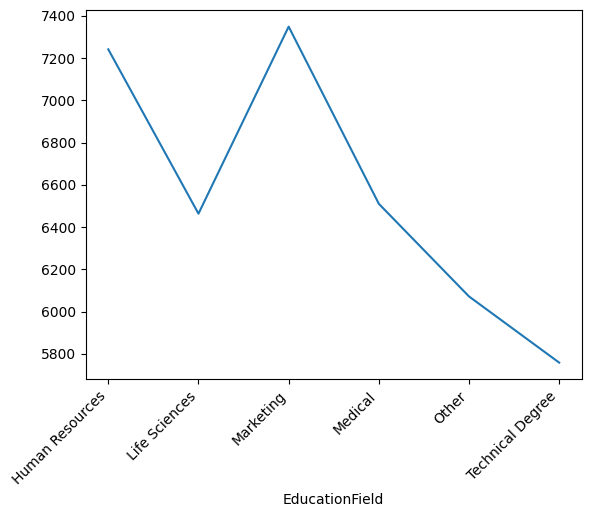

In [154]:
aux_var = df.groupby('EducationField')['MonthlyIncome']
aux_var.mean().plot()
plt.xticks(rotation=45, ha='right')

<Axes: xlabel='Education'>

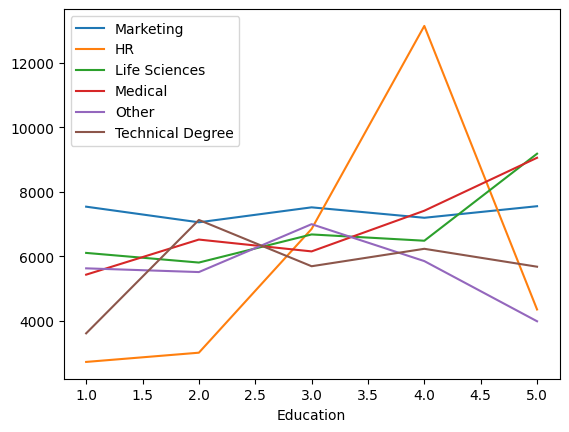

In [164]:
aux_MKT = df[df['EducationField']=='Marketing'].groupby('Education')['MonthlyIncome'].mean()
aux_HR = df[df['EducationField']=='Human Resources'].groupby('Education')['MonthlyIncome'].mean()
aux_LS = df[df['EducationField']=='Life Sciences'].groupby('Education')['MonthlyIncome'].mean()
aux_MED = df[df['EducationField']=='Medical'].groupby('Education')['MonthlyIncome'].mean()
aux_OTH = df[df['EducationField']=='Other'].groupby('Education')['MonthlyIncome'].mean()
aux_TCH = df[df['EducationField']=='Technical Degree'].groupby('Education')['MonthlyIncome'].mean()
pd.DataFrame({'Marketing' : aux_MKT, 'HR' : aux_HR, 'Life Sciences' : aux_LS, 'Medical' : aux_MED, 'Other' : aux_OTH, 'Technical Degree' : aux_TCH}).plot()

(array([0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5]),
 [Text(0.5, 0, '0.5'),
  Text(1.0, 0, '1.0'),
  Text(1.5, 0, '1.5'),
  Text(2.0, 0, '2.0'),
  Text(2.5, 0, '2.5'),
  Text(3.0, 0, '3.0'),
  Text(3.5, 0, '3.5'),
  Text(4.0, 0, '4.0'),
  Text(4.5, 0, '4.5'),
  Text(5.0, 0, '5.0'),
  Text(5.5, 0, '5.5')])

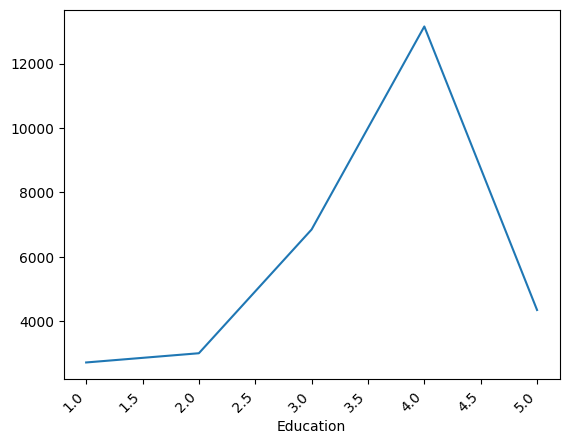

In [ ]:
aux_var.mean().plot()
plt.xticks(rotation=45, ha='right')
aux_var.mean().plot()
plt.xticks(rotation=45, ha='right')

<Axes: xlabel='MaritalStatus'>

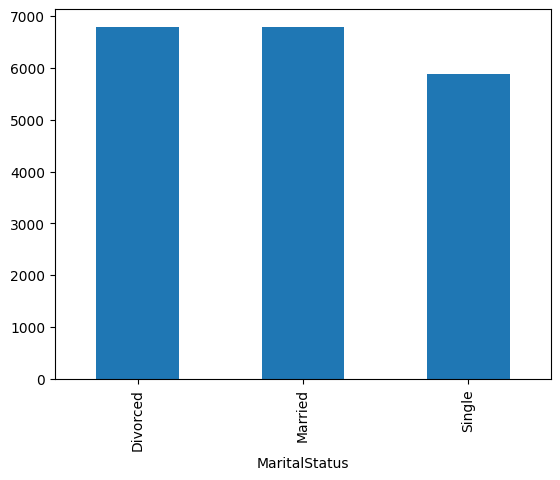

In [165]:
aux_var = df.groupby('MaritalStatus')['MonthlyIncome']
aux_var.mean().plot(kind='bar')

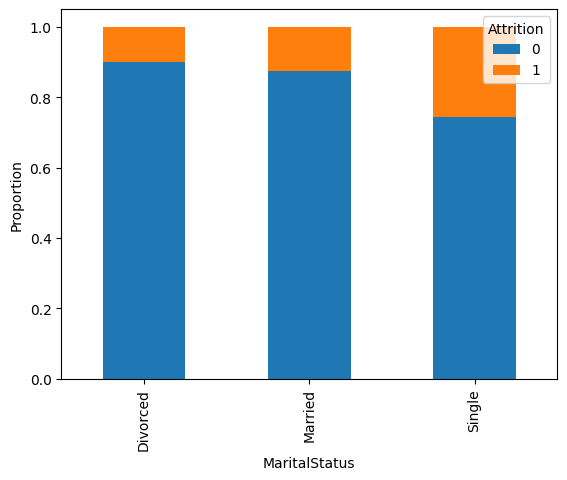

In [166]:
(
    df
    .groupby('MaritalStatus')['Attrition']
    .value_counts(normalize=True)
    .unstack()
    .plot(kind='bar', stacked=True)
)

plt.ylabel('Proportion')
plt.legend(title='Attrition')


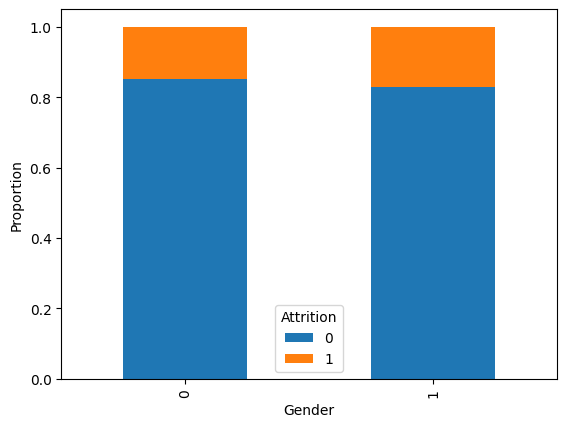

In [167]:
(
    df
    .groupby('Gender')['Attrition']
    .value_counts(normalize=True)
    .unstack()
    .plot(kind='bar', stacked=True)
)

plt.ylabel('Proportion')
plt.legend(title='Attrition')


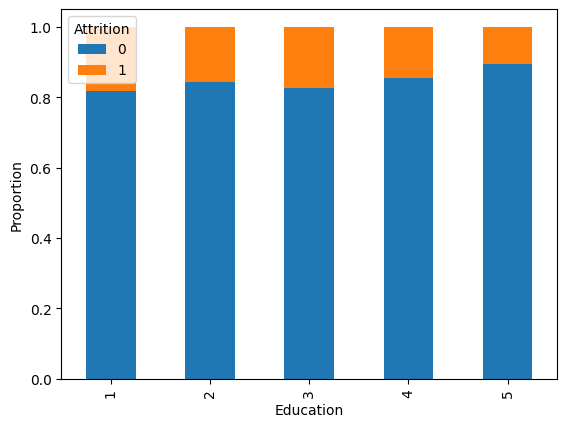

In [168]:
(
    df
    .groupby('Education')['Attrition']
    .value_counts(normalize=True)
    .unstack()
    .plot(kind='bar', stacked=True)
)

plt.ylabel('Proportion')
plt.legend(title='Attrition')


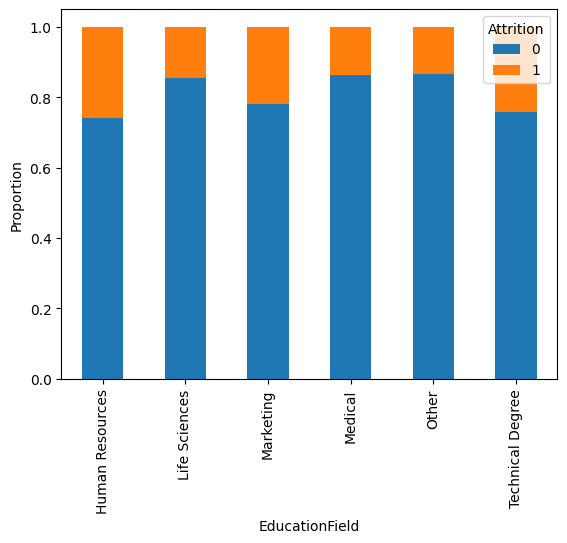

In [169]:
(
    df
    .groupby('EducationField')['Attrition']
    .value_counts(normalize=True)
    .unstack()
    .plot(kind='bar', stacked=True)
)

plt.ylabel('Proportion')
plt.legend(title='Attrition')


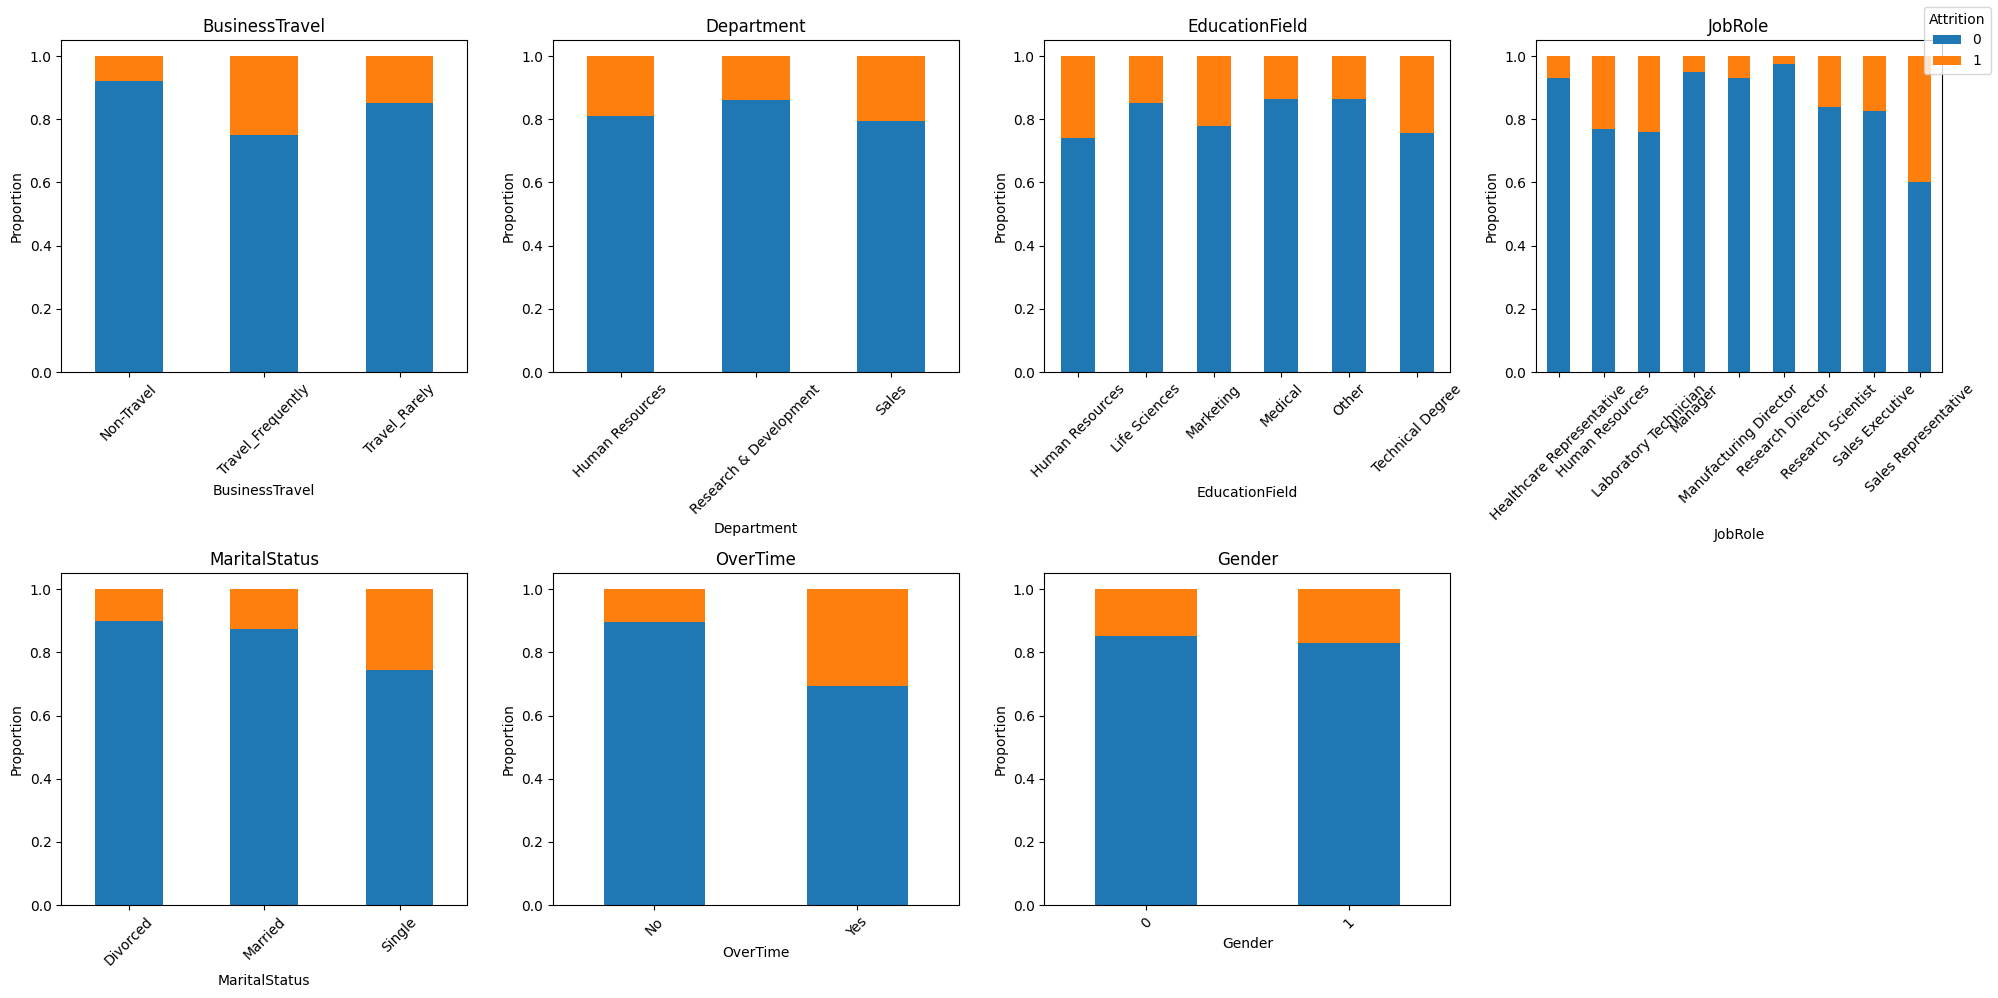

In [187]:
aux_categorical_cols = categorical_cols
aux_categorical_cols.append('Gender')

n_cols = 4
n_plots = len(aux_categorical_cols)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

def plot_attrition_by_category(df, col, ax):
    (
        df
        .groupby(col)['Attrition']
        .value_counts(normalize=True)
        .unstack()
        .plot(kind='bar', stacked=True, ax=ax, legend=False)
    )
    ax.set_title(col)
    ax.set_ylabel('Proportion')
    ax.tick_params(axis='x', rotation=45)
for i, col in enumerate(aux_categorical_cols):
    plot_attrition_by_category(df, col, axes[i])
#plot_attrition_by_category(df, 'Gender', axes[i])
# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# One legend for everything
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Attrition', loc='upper right')

plt.tight_layout()
plt.show()


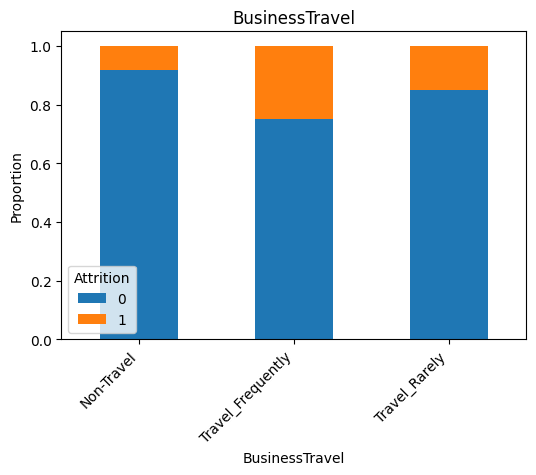

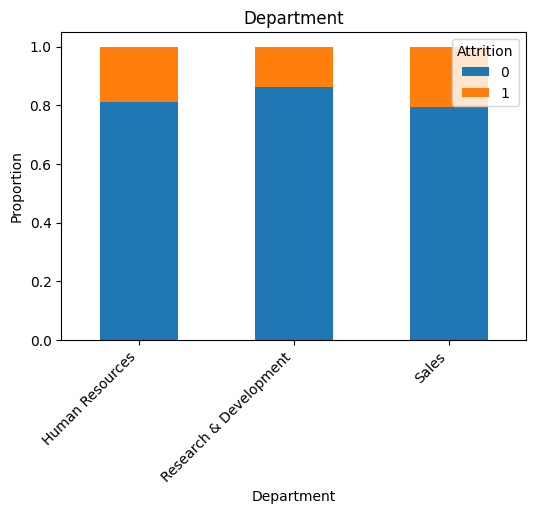

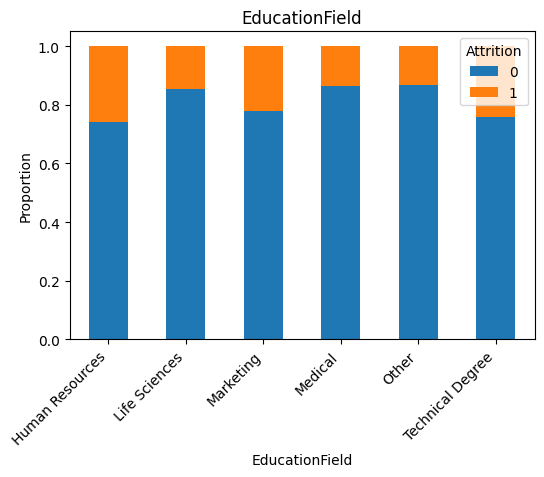

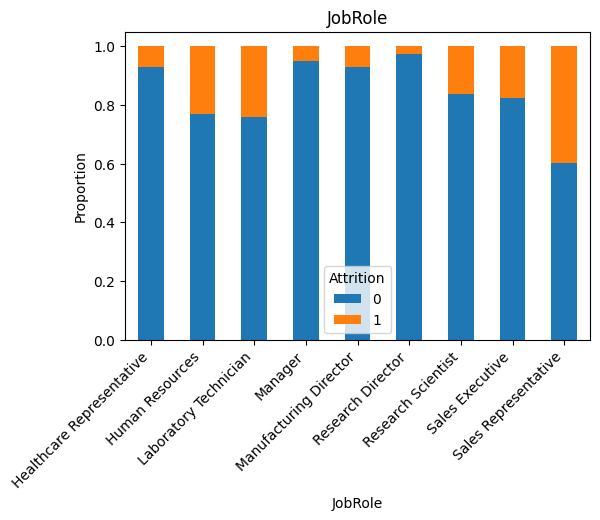

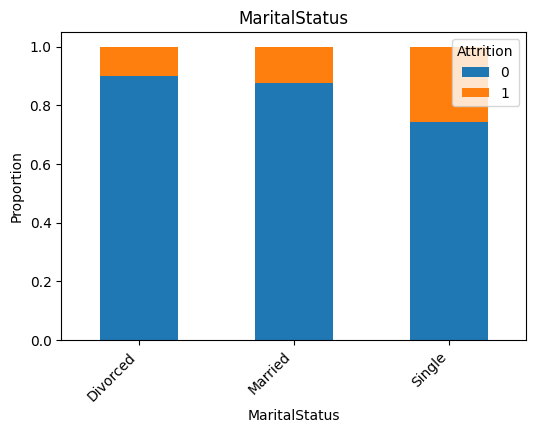

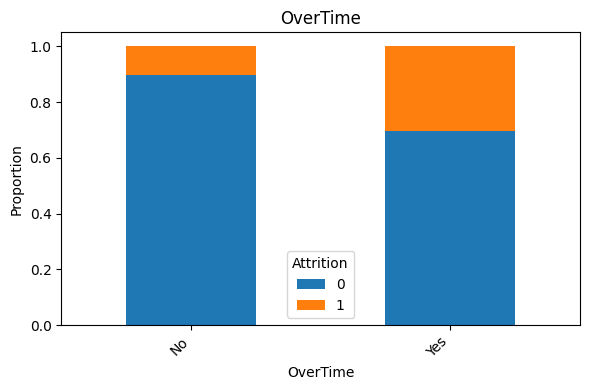

In [177]:
import matplotlib.pyplot as plt

def plot_attrition_by_category(df, col):
    (
        df
        .groupby(col)['Attrition']
        .value_counts(normalize=True)
        .unstack()
        .plot(kind='bar', stacked=True, figsize=(6,4))
    )
    plt.ylabel('Proportion')
    plt.title(col)
    plt.legend(title='Attrition')
    plt.xticks(rotation=45, ha='right')
    
    
for col in categorical_cols:
    plot_attrition_by_category(df, col)
plt.tight_layout()
plt.show()